<a href="https://colab.research.google.com/github/pierrot73/GenAIBootCamp/blob/Bootcamp/Week5_Day1_DC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge

In [ ]:
! pip install tensorflow numpy scikit-learn matplotlib seaborn







In [ ]:
ffn =tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10  , activation='softmax')
])

1. Load and Preprocess the MNIST Dataset



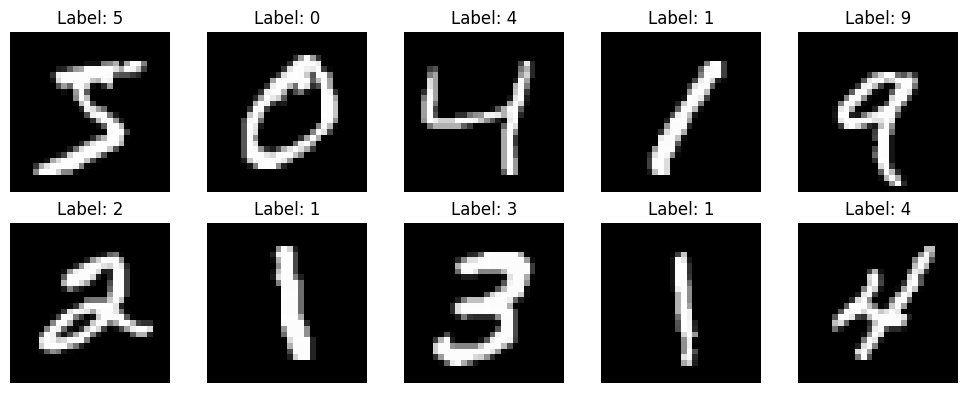

In [ ]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load the MNIST dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

# Normalize images to be between 0 and 1
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Convert labels to one-hot encoding
num_classes = 10
train_labels = to_categorical(train_labels, num_classes)
test_labels = to_categorical(test_labels, num_classes)

# Display sample images with labels
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap='gray')
    plt.title(f"Label: {train_labels[i].argmax()}")
    plt.axis('off')
plt.tight_layout()
plt.show()

2. Build a Fully Connected Neural Network



In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

# Define the model
model = Sequential([
    Flatten(input_shape=(28, 28)),            # Flatten 28x28 images into 784-dimensional vectors
    Dense(128, activation='relu'),            # First hidden layer with 128 neurons
    Dense(64, activation='relu'),             # Second hidden layer with 64 neurons
    Dense(10, activation='softmax')           # Output layer with 10 classes
])

# Compile the model
model.compile(
    loss='categorical_crossentropy',          # Loss function for multi-class classification
    optimizer='adam',                         # Adam optimizer
    metrics=['accuracy']                      # Evaluation metric
)

# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

3. Train the Neural Network



Epoch 1/10
750/750 - 6s - 8ms/step - accuracy: 0.9105 - loss: 0.3083 - val_accuracy: 0.9488 - val_loss: 0.1670
Epoch 2/10
750/750 - 3s - 4ms/step - accuracy: 0.9638 - loss: 0.1228 - val_accuracy: 0.9669 - val_loss: 0.1083
Epoch 3/10
750/750 - 3s - 4ms/step - accuracy: 0.9757 - loss: 0.0815 - val_accuracy: 0.9688 - val_loss: 0.1041
Epoch 4/10
750/750 - 4s - 6ms/step - accuracy: 0.9818 - loss: 0.0617 - val_accuracy: 0.9707 - val_loss: 0.0964
Epoch 5/10
750/750 - 4s - 6ms/step - accuracy: 0.9844 - loss: 0.0488 - val_accuracy: 0.9723 - val_loss: 0.0948
Epoch 6/10
750/750 - 5s - 6ms/step - accuracy: 0.9888 - loss: 0.0366 - val_accuracy: 0.9747 - val_loss: 0.0901
Epoch 7/10
750/750 - 5s - 6ms/step - accuracy: 0.9899 - loss: 0.0320 - val_accuracy: 0.9758 - val_loss: 0.0939
Epoch 8/10
750/750 - 6s - 7ms/step - accuracy: 0.9916 - loss: 0.0255 - val_accuracy: 0.9747 - val_loss: 0.1036
Epoch 9/10
750/750 - 6s - 8ms/step - accuracy: 0.9934 - loss: 0.0210 - val_accuracy: 0.9768 - val_loss: 0.1020
E

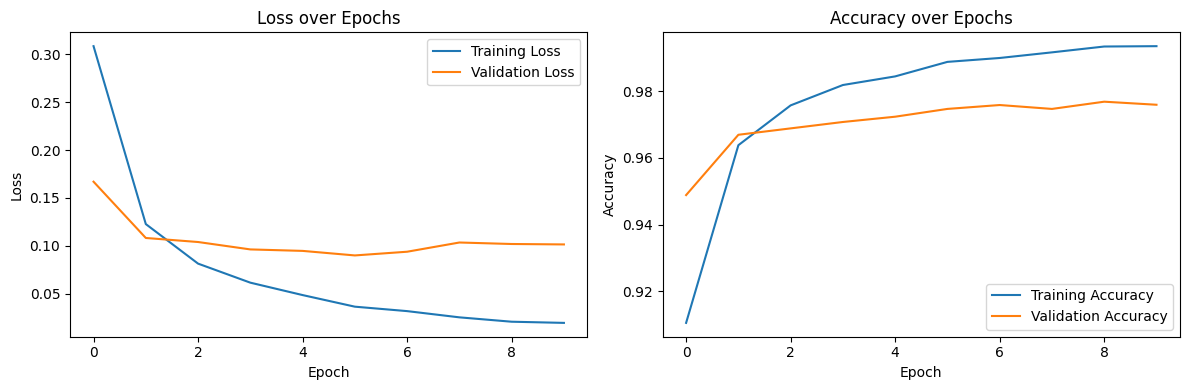

In [ ]:
import matplotlib.pyplot as plt

# Train the model
history = model.fit(
    train_images,                  # Training images
    train_labels,                  # Training labels (one-hot)
    epochs=10,                     # Number of epochs
    batch_size=64,                 # Batch size
    validation_split=0.2,          # Use 20% of training data for validation
    verbose=2                      # Verbosity mode
)

# Plot training & validation loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss over Epochs')
plt.legend()

# Plot training & validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

4. Evaluate the Model’s Performance



Test accuracy: 0.9773
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


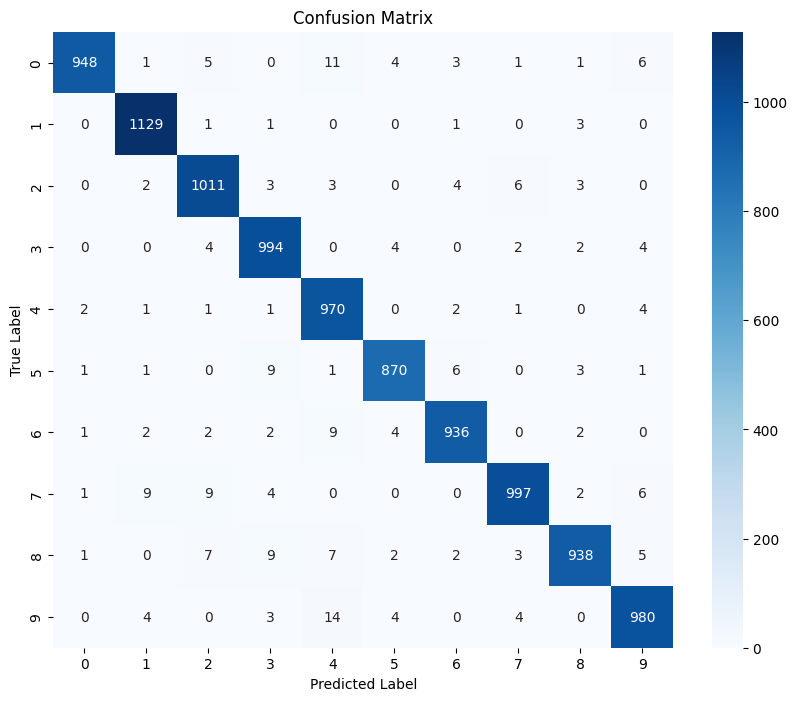

Digits the model struggles with the most (least accurate):
Digit 1: 99.47% accuracy
Digit 4: 98.78% accuracy
Digit 3: 98.42% accuracy
Digit 2: 97.97% accuracy
Digit 6: 97.70% accuracy
Digit 5: 97.53% accuracy
Digit 9: 97.13% accuracy
Digit 7: 96.98% accuracy
Digit 0: 96.73% accuracy
Digit 8: 96.30% accuracy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Assuming test_images and test_labels are your test dataset (labels one-hot encoded)
# If labels are not one-hot, convert them
test_labels_classes = np.argmax(test_labels, axis=1)

# 1. Compute accuracy on the test dataset
test_loss, test_accuracy = model.evaluate(test_images, test_labels, verbose=0)
print(f'Test accuracy: {test_accuracy:.4f}')

# 2. Predict classes for test images
predictions = np.argmax(model.predict(test_images), axis=1)

# 3. Generate the confusion matrix
cm = confusion_matrix(test_labels_classes, predictions)

# 4. Display the confusion matrix as a heatmap
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10),
            yticklabels=range(10))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 5. Identify digits with highest misclassification
misclassifications = cm.diagonal() - np.diag(cm)
# Alternatively, find which classes have the lowest diagonal (accuracy)
class_accuracy = np.diag(cm) / np.sum(cm, axis=1)
most_misclassified_digits = np.argsort(1 - class_accuracy)

print("Digits the model struggles with the most (least accurate):")
for digit in most_misclassified_digits:
    print(f"Digit {digit}: {class_accuracy[digit]*100:.2f}% accuracy")